In [1]:
# RESOURCE: https://www.kaggle.com/code/inboxhasibur/brain-tumor-classification-expert-system


import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from keras.applications.efficientnet_v2 import preprocess_input # make sure to use the adequate preprocessor
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S

# LOADING 

def folder_counts(root):
    return {cls: len(os.listdir(os.path.join(root, cls)))
            for cls in sorted(os.listdir(root))}

print("Training:", folder_counts(r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training"))
print("Testing :", folder_counts(r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Testing"))



Training: {'glioma_tumor': 826, 'meningioma_tumor': 822, 'no_tumor': 395, 'pituitary_tumor': 827}
Testing : {'glioma_tumor': 100, 'meningioma_tumor': 115, 'no_tumor': 105, 'pituitary_tumor': 74}


In [2]:
# make sure to match original model's preprocessing function
batch_size = 32

train_gen = ImageDataGenerator(
        validation_split = 0.2, 
        preprocessing_function = preprocess_input)
train_flow = train_gen.flow_from_directory(r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training", 
                                           target_size =(256, 256), 
                                           batch_size = batch_size, 
                                           subset ="training")

valid_flow = train_gen.flow_from_directory(r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training", 
                                           target_size =(256, 256), 
                                           batch_size = batch_size, 
                                           subset ="validation",
                                           shuffle = False) # aka validation

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.


In [3]:
test_gen = ImageDataGenerator(
        preprocessing_function = preprocess_input)
test_flow = test_gen.flow_from_directory(r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Testing", 
                                         target_size =(256, 256), 
                                         batch_size = batch_size,
                                         shuffle = False)

Found 394 images belonging to 4 classes.


In [4]:
# compute class weights to reduce class imbalance issues 

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_flow.classes),
    y=train_flow.classes
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.8687594553706506), 1: np.float64(0.8727203647416414), 2: np.float64(1.817246835443038), 3: np.float64(0.8674471299093656)}


In [5]:
# by default, the loaded model will include the original CNN 
#classifier designed for the ImageNet dataset
# since we want to reuse this model for a different problem,
# we need to omit the original fully connected layers, and 
# replace them with our own setting include_top = False will
# load the model without the fully connected layer

# load EfficientNetV2S model, with pretrained imagenet weights.
res = EfficientNetV2S(weights ='imagenet', include_top = False, 
               input_shape =(256, 256, 3))

# freeze the entire backbone
# keeps the original weights
res.trainable = False

In [6]:
# Block/stage-based fine-tuning (matched across backbones):
# unfreeze ONLY the final stage of the backbone, regardless of how many
# Keras layers or params that turns out to be. For EfficientNetV2-S the
# final stage is block 6 (the last MBConv group) plus the top conv/bn.
res.trainable = False
for layer in res.layers:
    layer.trainable = layer.name.startswith(('block6', 'top'))

# sanity check: which part of the backbone is unfrozen?
unfrozen = [l.name for l in res.layers if l.trainable]
print(f"Unfrozen {len(unfrozen)} backbone layers (final stage)")
print(f"  first: {unfrozen[0]}   last: {unfrozen[-1]}")

model = models.Sequential([
    res,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax') # num_classes, activation
    ], name='BrainTumor_EfficientNetV2S')

# early stopping to avoid overfitting
callback = keras.callbacks.EarlyStopping(monitor="val_loss",
                                         patience=5,
                                         verbose=1,
                                         restore_best_weights=True) # TODO: Review this parameter

learning_rate = 1e-2
epochs = 15

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy', 'precision', 'recall']
)

Unfrozen 226 backbone layers (final stage)
  first: block6a_expand_conv   last: top_activation


In [7]:
model.summary()

Model: "BrainTumor_EfficientNetV2S"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,697,828 (78.96 MB)

 Trainable params: 15,255,980 (58.20 MB)

 Non-trainable params: 5,441,848 (20.76 MB)

In [8]:
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


Total Parameters    : 20,697,828
Trainable Parameters: 15,255,980


In [9]:
# train the model 

import wandb
from wandb.integration.keras import WandbMetricsLogger

wandb.init(
    project="brain-tumor-detection",
    name="efficientnet-deeper-head",
    config={
        "backbone": "EfficientNetV2S",
        "unfreeze": "block6+top",
        "head": "256-128-128",     
        "dropout": [0.4, 0.3, 0.3],
        "epochs": epochs,
        "optimizer": "Adam",
        "lr": learning_rate,
        "batch_size": 32,
        "augmentation": False,
    },
)

history = model.fit(
    train_flow,
    epochs=epochs,
    validation_data=valid_flow,
    class_weight=class_weight_dict,
    callbacks=[WandbMetricsLogger(), callback],
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\rqg886\.netrc.
wandb: Currently logged in as: carobrasor (aml4ds) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.5855 - loss: 2.4560 - precision: 0.6479 - recall: 0.4919 - val_accuracy: 0.6719 - val_loss: 1.1397 - val_precision: 0.7895 - val_recall: 0.3927
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.7222 - loss: 0.7779 - precision: 0.7778 - recall: 0.6339 - val_accuracy: 0.5724 - val_loss: 7.0544 - val_precision: 0.6354 - val_recall: 0.5079
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.7353 - loss: 0.7358 - precision: 0.8054 - recall: 0.6578 - val_accuracy: 0.5515 - val_loss: 0.9017 - val_precision: 0.7045 - val_recall: 0.4119
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.7941 - loss: 0.5572 - precision: 0.8517 - recall: 0.7401 - val_accuracy: 0.6824 - val_loss: 0.7197 - val_precision: 0.7929 - val_recall: 0.6213
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.8102 - loss: 0.6184 - precision: 0.8650 - recall: 0.7645 - val_accuracy: 0.7225 - val_loss: 0.7332 


Best Validation Accuracy: 0.8255 (82.55%)


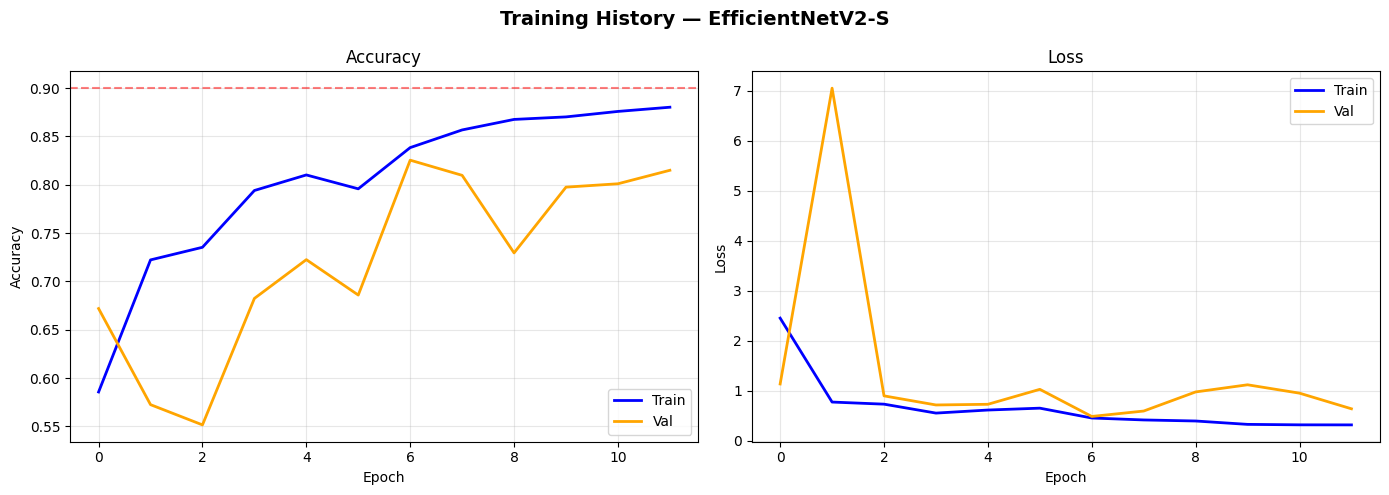

Training complete


In [10]:
best_val_acc = max(history.history['val_accuracy'])
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

import matplotlib.pyplot as plt

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — EfficientNetV2-S', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='blue',   lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange', lw=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='90% line')

axes[1].plot(history.history['loss'],     label='Train', color='blue',   lw=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='orange', lw=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Training complete")



Best Validation Precision: 0.8632 (86.32%)


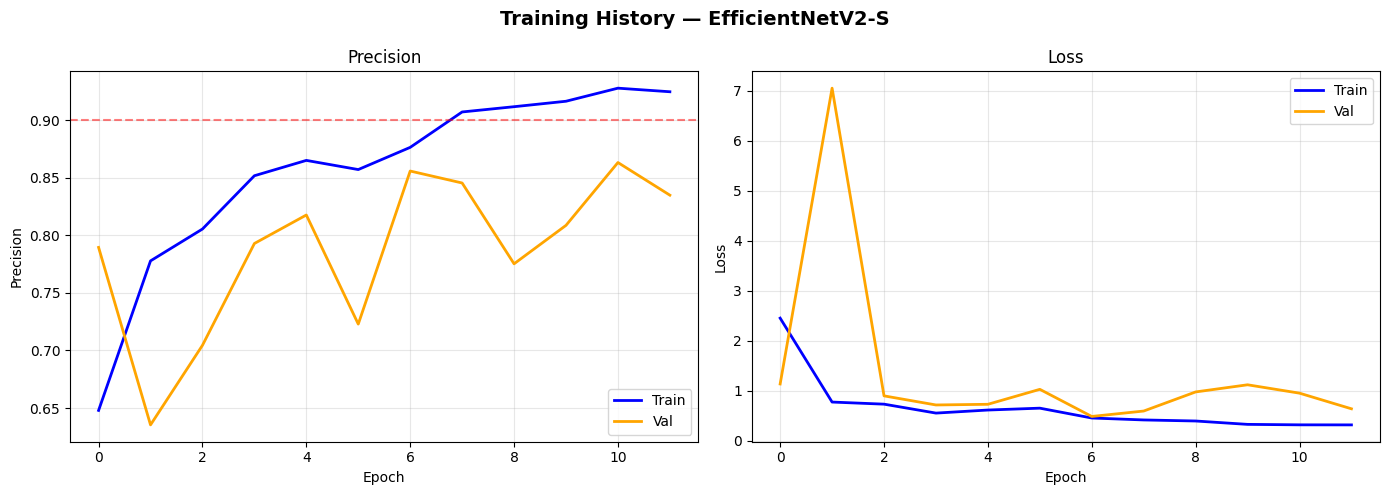

Training complete


In [11]:
best_val_precision = max(history.history['val_precision'])
print(f"\nBest Validation Precision: {best_val_precision:.4f} ({best_val_precision*100:.2f}%)")

import matplotlib.pyplot as plt

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — EfficientNetV2-S', fontsize=14, fontweight='bold')

axes[0].plot(history.history['precision'],     label='Train', color='blue',   lw=2)
axes[0].plot(history.history['val_precision'], label='Val',   color='orange', lw=2)
axes[0].set_title('Precision')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='90% line')

axes[1].plot(history.history['loss'],     label='Train', color='blue',   lw=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='orange', lw=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Training complete")


Best Validation Recall: 0.8115 (81.15%)


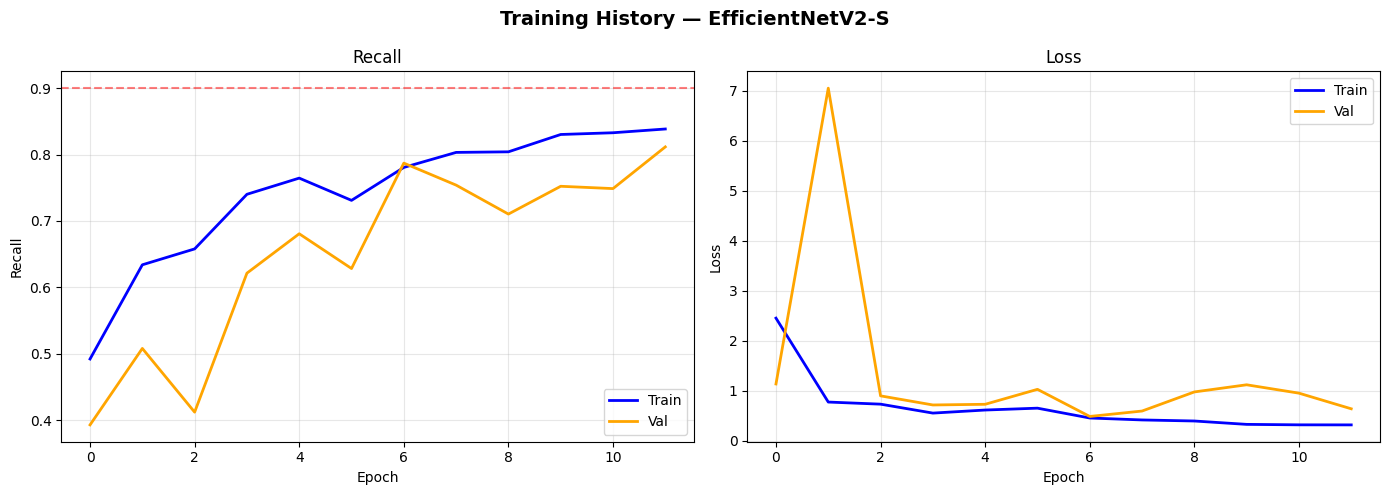

Training complete


In [12]:
best_val_recall = max(history.history['val_recall'])
print(f"\nBest Validation Recall: {best_val_recall:.4f} ({best_val_recall*100:.2f}%)")

import matplotlib.pyplot as plt

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — EfficientNetV2-S', fontsize=14, fontweight='bold')

axes[0].plot(history.history['recall'],     label='Train', color='blue',   lw=2)
axes[0].plot(history.history['val_recall'], label='Val',   color='orange', lw=2)
axes[0].set_title('Recall')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Recall')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='90% line')

axes[1].plot(history.history['loss'],     label='Train', color='blue',   lw=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='orange', lw=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Training complete")

In [13]:
result = model.evaluate(test_flow)

print('The model achieved a loss of %.2f and,'
      'accuracy of %.2f%%.' % (result[0], result[1]*100))

wandb.log({"test_loss": result[0], "test_accuracy": result[1]})
wandb.finish()

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6041 - loss: 1.4457 - precision: 0.6667 - recall: 0.5685
The model achieved a loss of 1.45 and,accuracy of 60.41%.


epoch/accuracy,▁▄▅▆▆▆▇▇████
epoch/epoch,▁▂▂▃▄▄▅▅▆▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▂▂▂▂▂▁▁▁▁▁▁
epoch/precision,▁▄▅▆▆▆▇▇████
epoch/recall,▁▄▄▆▇▆▇▇▇███
epoch/val_accuracy,▄▂▁▄▅▄██▆▇▇█
epoch/val_loss,▂█▁▁▁▂▁▁▂▂▁▁
epoch/val_precision,▆▁▃▆▇▄█▇▅▆█▇
epoch/val_recall,▁▃▁▅▆▅█▇▆▇▇█
+2,...


In [14]:
#getpredictions

In [15]:
import numpy as np

def predict_with_threshold(probs, no_tumor_threshold):
    "Favors predicting tumor even when no tumor was initially predicted"
    preds = np.argmax(probs, axis=1)
    # TODO: CONTINUE AND PREDICT WITH THRESHOLD
    return preds


probs = model.predict(test_flow)              # shape: (n_samples, 4)
y_pred = np.argmax(probs, axis=1)             # predicted class index per image
y_true = test_flow.classes                    # true class index per image
class_names = list(test_flow.class_indices.keys())   # ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step


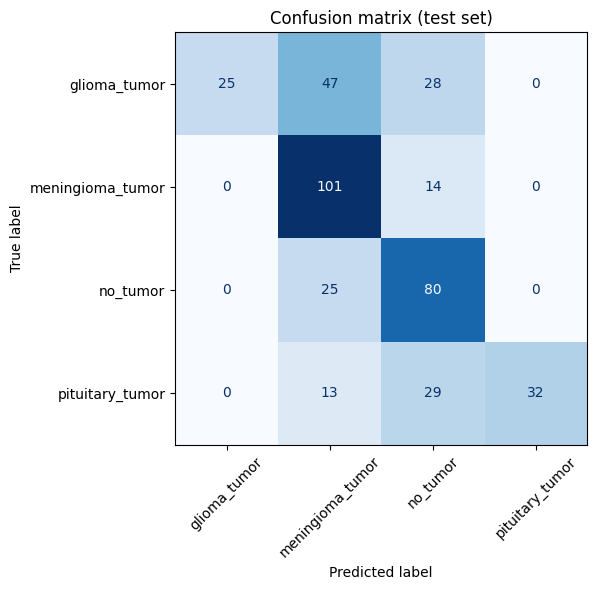

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.show()


In [17]:
def show_examples(true_cls, pred_cls, n=6):
    """Show n images where true class == true_cls and predicted == pred_cls."""
    idxs = np.where((y_true == true_cls) & (y_pred == pred_cls))[0]
    if len(idxs) == 0:
        print(f"No samples: true={class_names[true_cls]}, predicted={class_names[pred_cls]}")
        return
    idxs = idxs[:n]

    fig, axes = plt.subplots(1, len(idxs), figsize=(3*len(idxs), 3))
    if len(idxs) == 1:
        axes = [axes]

    filenames = test_flow.filenames
    for ax, i in zip(axes, idxs):
        img_path = os.path.join(test_flow.directory, filenames[i])
        img = plt.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"conf={probs[i, pred_cls]:.2f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(f"true: {class_names[true_cls]}  →  predicted: {class_names[pred_cls]}", y=1.05)
    plt.tight_layout(); plt.show()


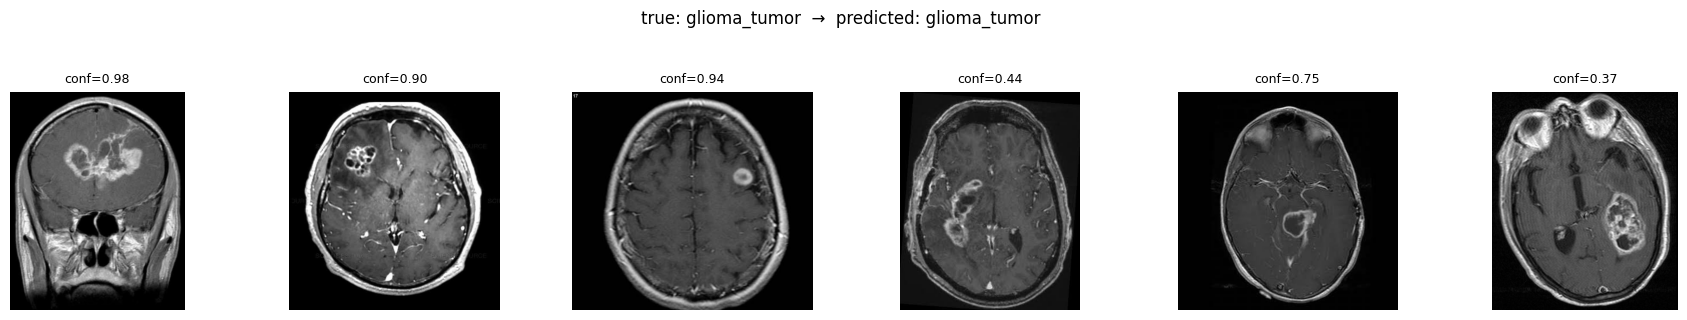

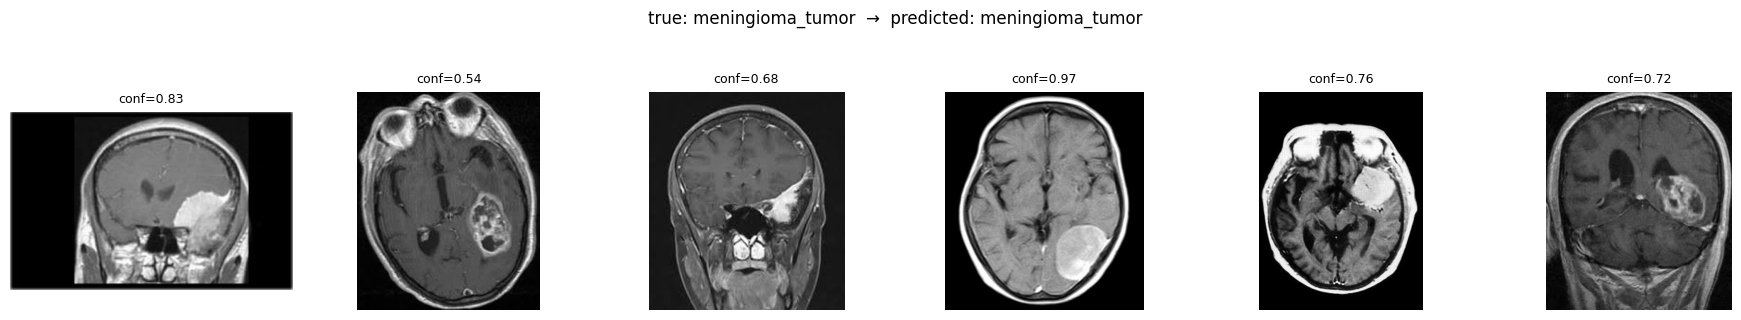

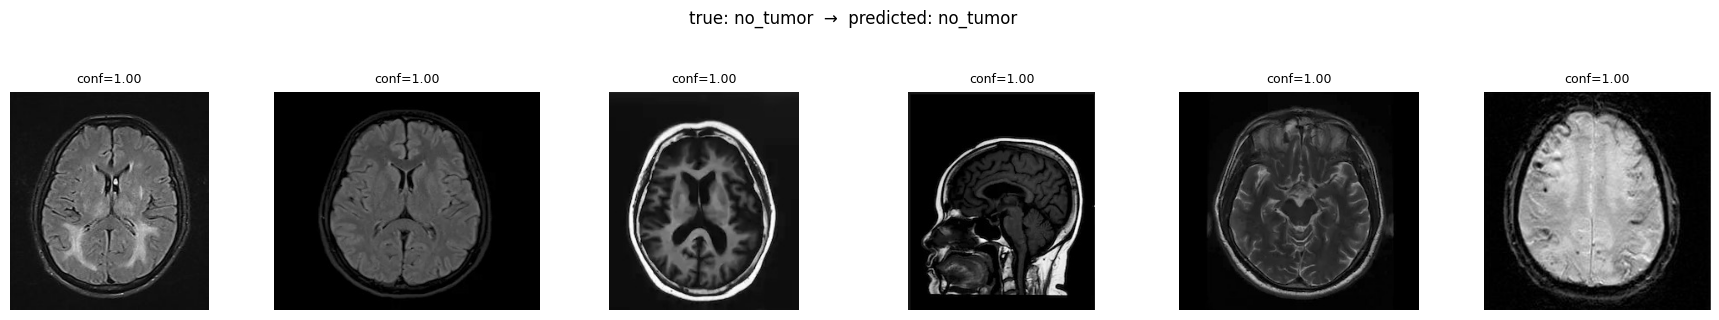

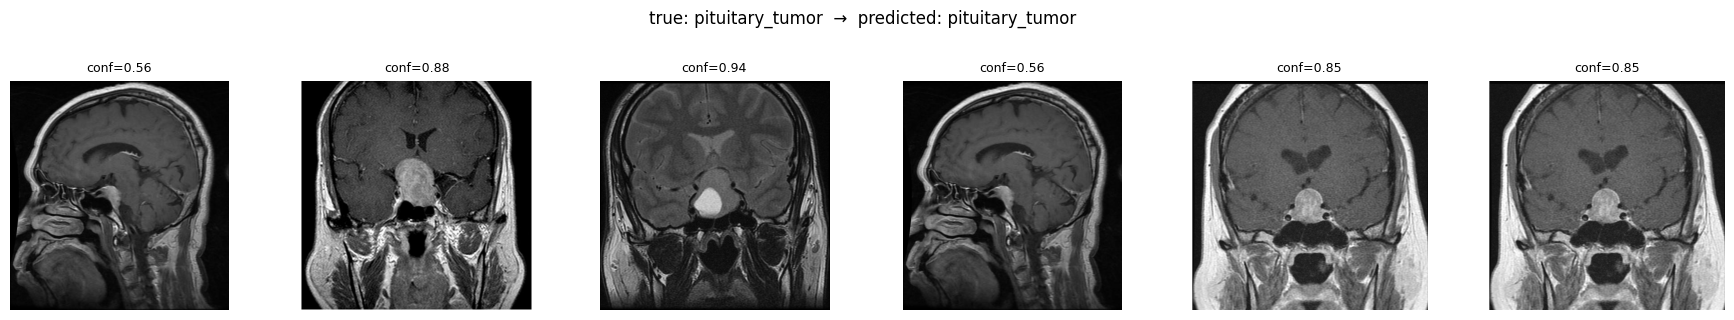

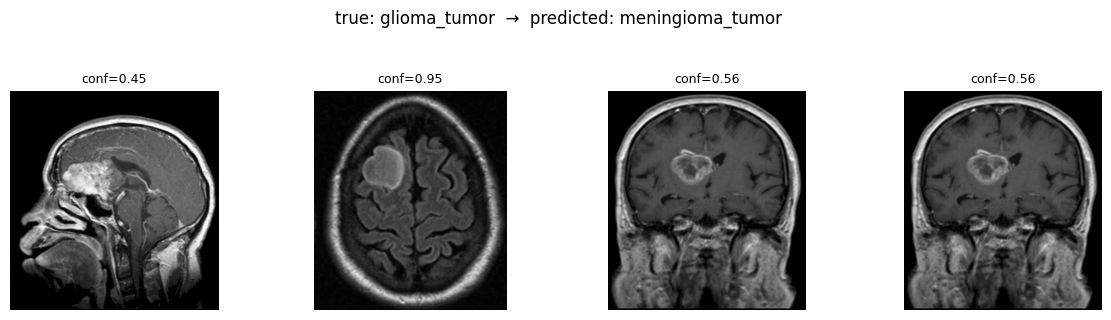

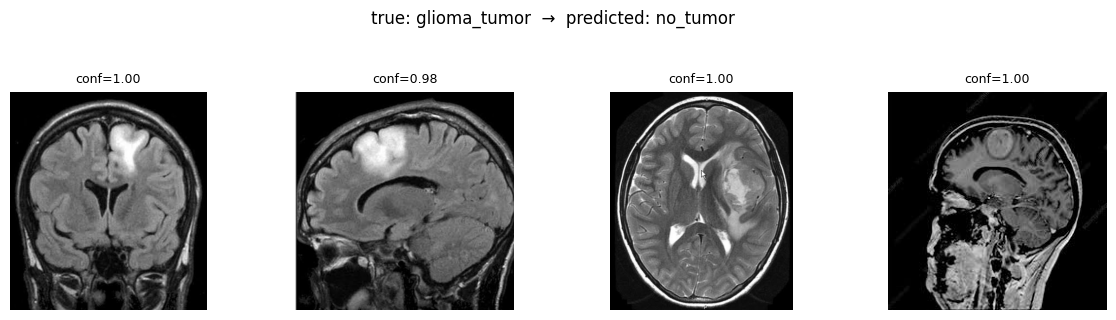

No samples: true=glioma_tumor, predicted=pituitary_tumor


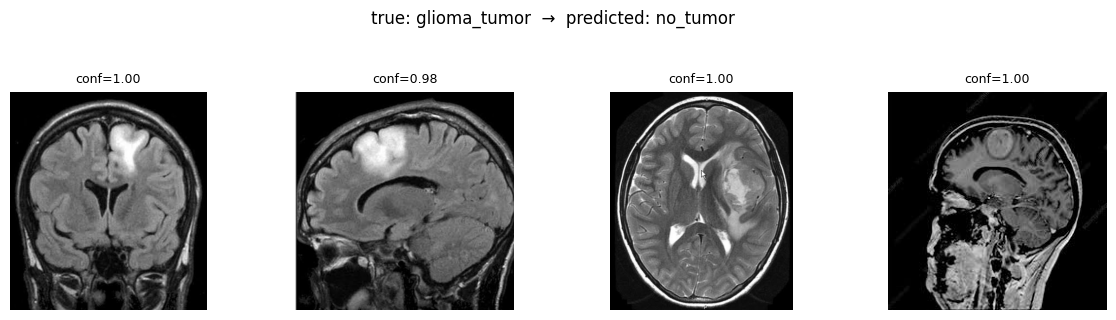

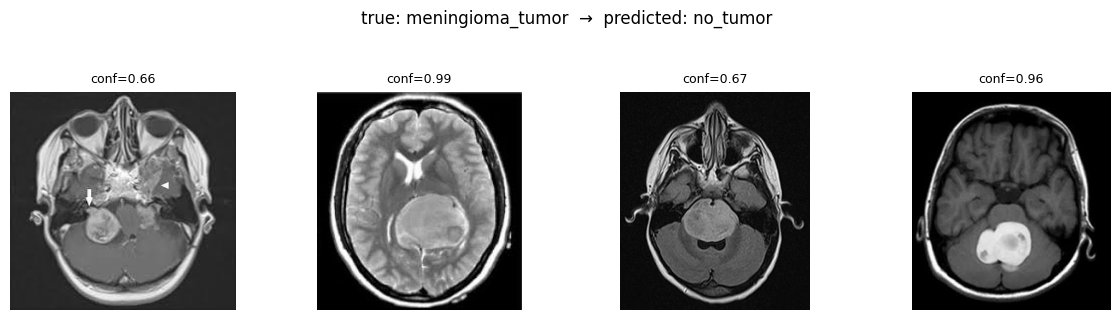

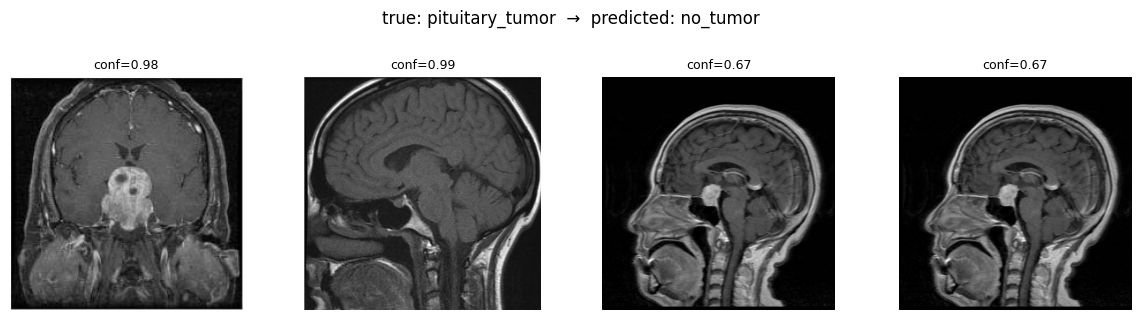

In [18]:
# Correct predictions (diagonal) — sanity check
for c in range(4):
    show_examples(true_cls=c, pred_cls=c, n=6)

# All mistakes for the "glioma" class (row 0, off-diagonal)
for pred in range(4):
    if pred != 0:
        show_examples(true_cls=0, pred_cls=pred, n=4)

# All false positives for "no_tumor" (column 2, off-diagonal) — these are the dangerous ones in a medical context
for true in range(4):
    if true != 2:
        show_examples(true_cls=true, pred_cls=2, n=4)


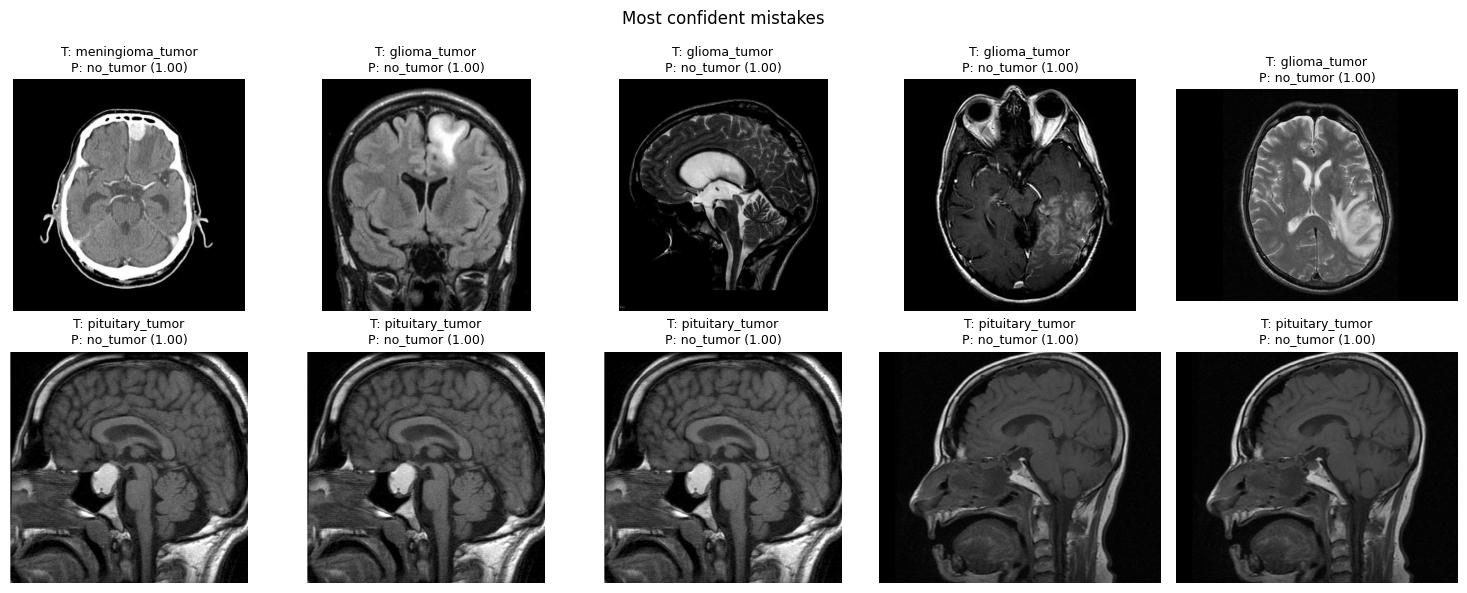

In [19]:
import os

wrong = np.where(y_pred != y_true)[0]
confidence_in_wrong_answer = probs[wrong, y_pred[wrong]]
top_wrong = wrong[np.argsort(-confidence_in_wrong_answer)][:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, i in zip(axes.flat, top_wrong):
    img = plt.imread(os.path.join(test_flow.directory, test_flow.filenames[i]))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T: {class_names[y_true[i]]}\nP: {class_names[y_pred[i]]} ({probs[i, y_pred[i]]:.2f})",
                 fontsize=9)
    ax.axis('off')
plt.suptitle("Most confident mistakes")
plt.tight_layout(); plt.show()


## SHAP

Pixels with positive values are shown in red, while pixels with negative values are shown in blue. This means that red pixels has a positive contribution to a specific class. Grey-ish pixels are close to 0, indicating that the model does not pay much attention to these pixels.

SHAP needs a masker to perturb the input images. A masker is a function that takes an input image and returns a perturbed version of it in which some parts are blurred or blacked out. shap.Explainer uses these perturbed versions to measure how much each pixel contributes to the model prediction

In [20]:
import shap

c:\Users\rqg886\Desktop\brain-tumor-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
# Collect all preprocessed test images into one array (test_flow has shuffle=False, so order matches y_true)
test_flow.reset()
all_imgs = np.concatenate([next(test_flow)[0] for _ in range(len(test_flow))], axis=0)
print("Test images shape:", all_imgs.shape)   # expect (394, 256, 256, 3)

# SHAP wants a numpy-returning prediction function
def f(x):
    return model.predict(x, verbose=0)

# Masker that blurs masked-out pixels
masker_blur = shap.maskers.Image("blur(32,32)", all_imgs[0].shape)

# 4 classes, not 3
explainer = shap.Explainer(f, masker_blur, output_names=class_names)

Test images shape: (394, 256, 256, 3)


Filename:  glioma_tumor\image(54).jpg
True:      glioma_tumor
Predicted: no_tumor

Class probabilities:
  P(glioma_tumor      ) = 0.0034
  P(meningioma_tumor  ) = 0.1518
  P(no_tumor          ) = 0.8339
  P(pituitary_tumor   ) = 0.0109


PartitionExplainer explainer: 2it [01:00, 60.77s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


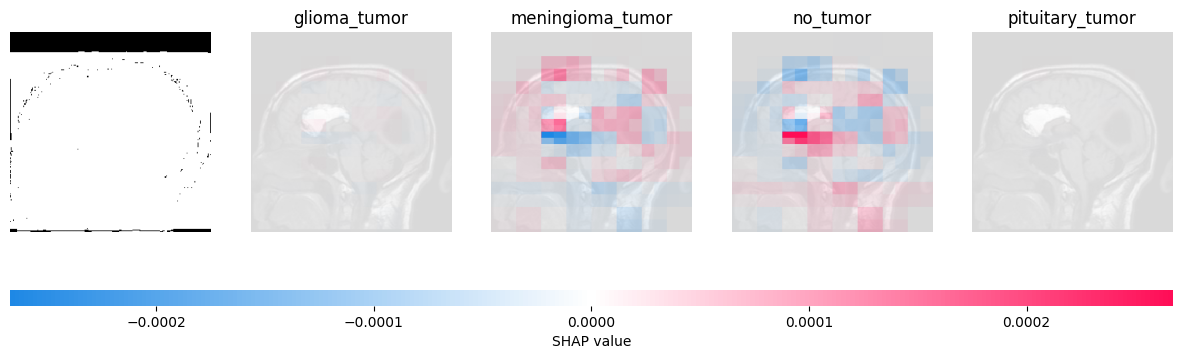

In [22]:
i = 50   # any index in [0, 393]

print(f"Filename:  {test_flow.filenames[i]}")
print(f"True:      {class_names[y_true[i]]}")
print(f"Predicted: {class_names[y_pred[i]]}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, probs[i]):
    print(f"  P({cls:<18}) = {p:.4f}")

# Pick an image to explain (must be in [0, 393])
ind = [i]           
shap_values_ = explainer(all_imgs[ind], max_evals=2000, batch_size=50)

shap.image_plot(shap_values_)

Filename:  no_tumor\image(82).jpg
True:      no_tumor
Predicted: no_tumor

Class probabilities:
  P(glioma_tumor      ) = 0.0000
  P(meningioma_tumor  ) = 0.0001
  P(no_tumor          ) = 0.9998
  P(pituitary_tumor   ) = 0.0000


PartitionExplainer explainer: 2it [00:54, 54.37s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


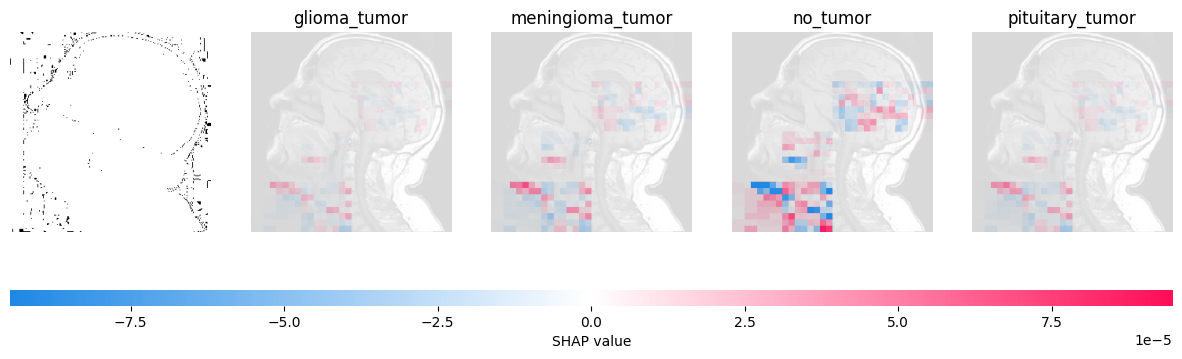

In [23]:
i = 300   # any index in [0, 393]

print(f"Filename:  {test_flow.filenames[i]}")
print(f"True:      {class_names[y_true[i]]}")
print(f"Predicted: {class_names[y_pred[i]]}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, probs[i]):
    print(f"  P({cls:<18}) = {p:.4f}")

ind = [i]           
shap_values_ = explainer(all_imgs[ind], max_evals=2000, batch_size=50)

shap.image_plot(shap_values_)

Filename:  glioma_tumor\image(1).jpg
True:      glioma_tumor
Predicted: glioma_tumor

Class probabilities:
  P(glioma_tumor      ) = 0.9832
  P(meningioma_tumor  ) = 0.0163
  P(no_tumor          ) = 0.0002
  P(pituitary_tumor   ) = 0.0003


PartitionExplainer explainer: 2it [00:53, 53.31s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


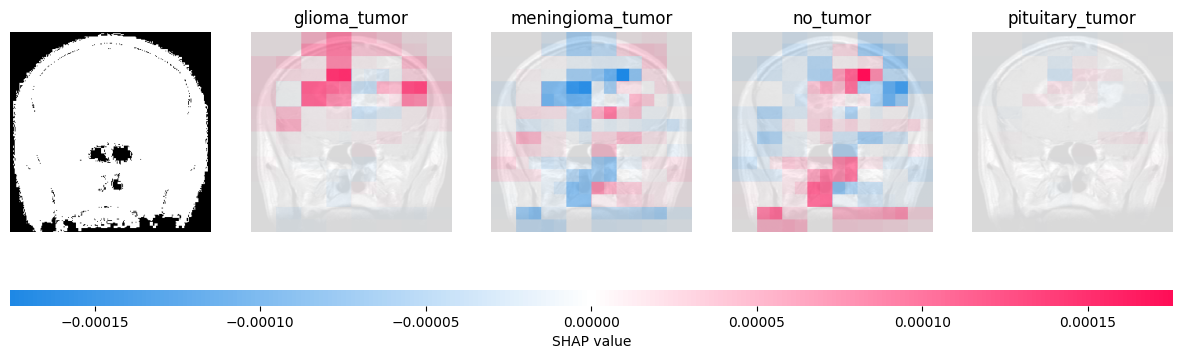

In [24]:
i = 0   # any index in [0, 393]

print(f"Filename:  {test_flow.filenames[i]}")
print(f"True:      {class_names[y_true[i]]}")
print(f"Predicted: {class_names[y_pred[i]]}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, probs[i]):
    print(f"  P({cls:<18}) = {p:.4f}")

ind = [i]           
shap_values_ = explainer(all_imgs[ind], max_evals=2000, batch_size=50)

shap.image_plot(shap_values_)